In [201]:
%config InlineBackend.figure_format = 'svg'
import warnings
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
warnings.filterwarnings('ignore')
plt.style.use('dark_background')

# Logistic Regression & Classification

In a regression problem, the algorithms outputs continous numerical values $y \in \R$, based on a set of independent input parameters. In a classification problem, the difference is that the values $y$ take on a finite number of discrete values. In this section, we will focus on binary classification, where $y$ takes on exactly two values: $y \in \{0, 1\}$. $y=0$ is referred to as the **negative class** and $y=1$ is referred to as the **positive class**. In particular we will take a look at logistic regression and  how it can be used to tackle binary classification problems.

Recalling the hypothesis for linear regression:

$$
h_{\theta}(x) = \theta^{T}x
$$

Can we use this hypothesis for logistic regression as well? One problem is that it outputs values in $\R$, which doesn't make it useful for classification. But it is a good starting point. The idea is to take the linear regression hypothesis and project it to the interval $[0, 1]$. If we can achieve that, we can interpret the continous output of this new hypothesis to be probabilities associated with the **negative class** and **positive class** respectively:
$$
\begin{align*}
P(y=1 \mid x; \theta) &= h_{\theta}(x) &\text{(Positive Class)} \\
P(y=0 \mid x; \theta) &= 1 - h_{\theta}(x) &\text{(Negative Class)}
\end{align*}
$$

To project the output of the linear regression hypothesis, we need a function $g(z)$, such that $g: \R\to[0, 1]$. The **sigmoid function** defined as follows is one of the functions that fit this requirement:

$$
g(z) = \frac{1}{1+ e^{-z}}
$$

and thus, the logistic regression hypothesis can be written as:
$$
\boxed{h_{\theta}(x) = g(\theta^{T}x) = \frac{1}{1 + e^{-\theta^{T}x}}}
$$

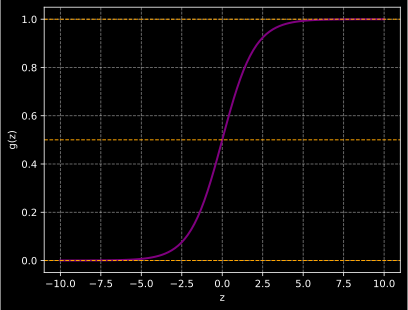

In [90]:
x = np.linspace(-10, 10, 100)
y = 1 / (1 + np.exp(-x))

plt.plot(x, y, label='sigmoid(x)', color='purple', linewidth=2)
plt.axhline(0.5, color='orange', linestyle='--', label='y=0.5', linewidth=1)
plt.axhline(0, color='orange', linestyle='--', label='y=0', linewidth=1)
plt.axhline(1, color='orange', linestyle='--', label='y=1', linewidth=1)
plt.xlabel('z')
plt.ylabel('g(z)')
plt.grid(linestyle='--', alpha=0.5)
plt.show()

## Estimating the parameters $(\theta)$ - Gradient Ascent
Similar to how we estimated $\theta$ using the **maximum likelihood estimator** in the case of linear regression under certain probabilistic assumptions about the training data, we can use the same approach here. Let's start with what we know:
$$
\begin{align*}
P(y=1 \mid x; \theta) &= h_{\theta}(x) \\
P(y=0 \mid x; \theta) &= 1 - h_{\theta}(x)
\end{align*}
$$

Since $y\in\{0,1\}$, we can exploit this to write:
$$
P(y \mid x; \theta) = \big(h_{\theta}(x)\big)^y\big(1-h_{\theta}(x)\big)^{1-y}
$$

Assuming that the training samples are IID(independent and identically distributed), we can write:
$$
\begin{align*}
P(y\mid X; \theta) &= \prod_{i=1}^{n}P\big(y^{(i)}\mid x^{(i)}; \theta\big) \\
&= \prod_{i=1}^{n}\big(h_{\theta}(x^{(i)})\big)^{y^{(i)}}\big(1-h_{\theta}(x^{(i)})\big)^{1-y^{(i)}}
\end{align*}
$$

But this is just the likelihood of $\theta$ as we have defined it in the case of linear regression:
$$
L(\theta) = L(\theta\mid X, y) = P(y \mid X; \theta)
$$

Maximizing $L(\theta)$ is equivalent to maximizing the log-likelihood $\ell(\theta)$:
$$
\begin{align*}
\ell(\theta) &= \ln\big(L(\theta)\big) \\
&= \ln\Bigg(\prod_{i=1}^{n}\big(h_{\theta}(x^{(i)})\big)^{y^{(i)}}\big(1-h_{\theta}(x^{(i)})\big)^{1-y^{(i)}}\Bigg) \\
&= \sum_{i=1}^{n}\ln\Big(\big(h_{\theta}(x^{(i)})\big)^{y^{(i)}}\big(1-h_{\theta}(x^{(i)})\big)^{1-y^{(i)}}\Big) \\
&= \sum_{i=1}^{n} y^{(i)}\ln\big(h_{\theta}(x^{(i)})\big) + (1-y^{(i)})\ln\big(1-h_{\theta}(x^{(i)})\big) \\
\end{align*}
$$

To maximize $\ell(\theta)$, we employ the **gradient ascent algorithm**, where we perform small incremental updates to the parameters, and eventually converge to the global maxima:
$$
\begin{align*}
\theta_{j} &:= \theta_{j} + \alpha\frac{\partial}{\partial\theta_{j}}\ell(\theta) \\
\frac{\partial}{\partial\theta_{j}}\ell(\theta) &= \frac{\partial}{\partial\theta_{j}}\Bigg(\sum_{i=1}^{n} y^{(i)}\ln\big(h_{\theta}(x^{(i)})\big) + (1-y^{(i)})\ln\big(1-h_{\theta}(x^{(i)})\big)\Bigg) \\
&= \sum_{i=1}^{n}\frac{\partial}{\partial\theta_{j}}\Big(y^{(i)}\ln\big(h_{\theta}(x^{(i)})\big) + (1-y^{(i)})\ln\big(1-h_{\theta}(x^{(i)})\big)\Big) \\
&= \sum_{i=1}^{n} \Bigg(\frac{y^{(i)}}{h_{\theta}(x^{(i)})} - \frac{1 - y^{(i)}}{1 - h_{\theta}(x^{(i)})}\Bigg)\cdot\frac{\partial}{\partial\theta_{j}}h_{\theta}(x^{(i)}) \\
&= \sum_{i=1}^{n} \Bigg(\frac{y^{(i)}}{h_{\theta}(x^{(i)})} - \frac{1 - y^{(i)}}{1 - h_{\theta}(x^{(i)})}\Bigg)\cdot\frac{\partial}{\partial\theta_{j}}\Bigg(\frac{1}{1 + e^{-\theta^{T}x^{(i)}}}\Bigg) \\
&= \sum_{i=1}^{n} \Bigg(\frac{y^{(i)}}{h_{\theta}(x^{(i)})} - \frac{1 - y^{(i)}}{1 - h_{\theta}(x^{(i)})}\Bigg)\cdot\frac{e^{-\theta^{T}x^{(i)}}}{\big(1 + e^{-\theta^{T}x^{(i)}}\big)^2}\cdot x_{j}^{(i)} \\
&= \sum_{i=1}^{n} \Bigg(\frac{y^{(i)}\big(1 - h_{\theta}(x^{(i)})\big) - \big(1 - y^{(i)}\big)h_{\theta}(x^{(i)})}{h_{\theta}(x^{(i)})\big(1 - h_{\theta}(x^{(i)})\big)}\Bigg)\cdot h_{\theta}(x^{(i)})\big(1 - h_{\theta}(x^{(i)})\big)\cdot x_{j}^{(i)} \\
&= \sum_{i=1}^{n} \Big(y^{(i)} - h_{\theta}(x^{(i)})\Big)x_{j}^{(i)}
\end{align*}
$$

Thus, we arrive at the **batch gradient ascent** and **stochastic gradient ascent** rules as below:
$$
\boxed{\theta_{j} := \theta_{j} + \alpha\sum_{i=1}^{n} \Big(y^{(i)} - h_{\theta}(x^{(i)})\Big)x_{j}^{(i)}}\quad\text{(Batch gradient ascent)}
$$
$$
\boxed{\theta_{j} := \theta_{j} + \alpha\Big(y^{(i)} - h_{\theta}(x^{(i)})\Big)x_{j}^{(i)}}\quad\text{(Stochastic gradient ascent)}
$$

Notice that the update rule is exactly same as the update rule that we dervied in Linear regression. The difference being of course that the hypotheses are different in both cases. This turns out to not be a coincidence but a characteristic of a more general class of regression algorithms, as we will see in *Generalized Linear Models*. Another interesting result we obtain from the above derivation is regarding the sigmoid function:
$$
g'(z) = g(z)(1-g(z))
$$

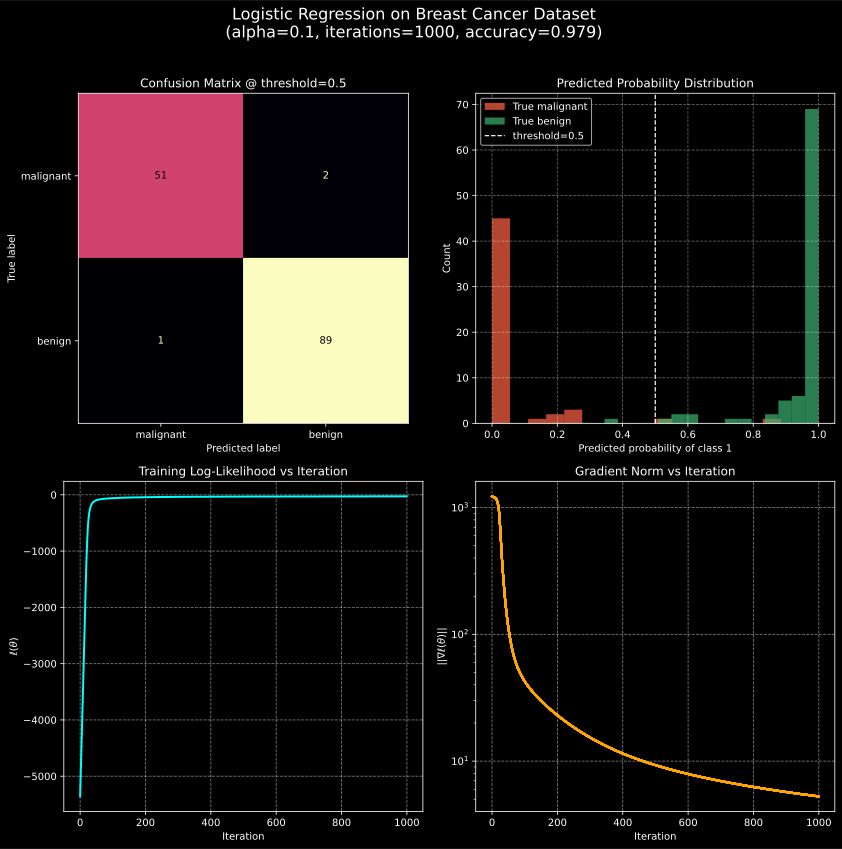

In [208]:
data = load_breast_cancer()
X = data.data
Y = data.target

d = X.shape[1]  # number of features
n = X.shape[0]  # number of samples

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42, stratify=Y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = np.column_stack([np.ones(X_train.shape[0]), X_train])  # Add intercept term
X_test = np.column_stack([np.ones(X_test.shape[0]), X_test])  # Add intercept term

def sigmoid(z):
    z = np.clip(z, -500, 500)  # Prevent overflow in exp
    return 1.0 / (1.0 + np.exp(-z))

def hypothesis(x, theta):
    return sigmoid(x @ theta)

def log_likelihood(X, Y, theta):
    p = hypothesis(X, theta)
    eps = 1e-12 # Prevent log(0) by clipping probabilities to a small range
    p = np.clip(p, eps, 1 - eps)
    return np.sum(Y * np.log(p) + (1 - Y) * np.log(1 - p))

def logistic_regression(X, Y, alpha=0.1, iterations=1000):
    log_likelihood_history = np.zeros(iterations)
    gradient_history = np.zeros((iterations, X.shape[1]))

    theta = np.ones(X.shape[1])
    for it in range(iterations):
        gradient = X.T @ (Y - hypothesis(X, theta))
        theta = theta + alpha * gradient / n # Scale by number of samples for stability
        log_likelihood_history[it] = log_likelihood(X, Y, theta)
        gradient_history[it] = np.linalg.norm(gradient) # norm of gradient = magnitude of gradient vector
    
    return theta, log_likelihood_history, gradient_history

alpha = 0.1
iterations = 1000

theta, log_likelihood_history, gradient_history = logistic_regression(X_train, Y_train, alpha, iterations)
Y_prob = hypothesis(X_test, theta)
Y_preds = (Y_prob >= 0.5).astype(int)
accuracy = np.mean(Y_preds == Y_test)

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
cm = confusion_matrix(Y_test, Y_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap='magma', ax=axes[0, 0], colorbar=False)
axes[0, 0].set_title('Confusion Matrix @ threshold=0.5')
axes[0, 0].set_xlabel('Predicted label')
axes[0, 0].set_ylabel('True label')

axes[0, 1].hist(Y_prob[Y_test == 0], bins=16, alpha=0.7, color='tomato', label='True {}'.format(data.target_names[0]))
axes[0, 1].hist(Y_prob[Y_test == 1], bins=16, alpha=0.7, color='mediumseagreen', label='True {}'.format(data.target_names[1]))
axes[0, 1].axvline(0.5, color='white', linestyle='--', linewidth=1.2, label='threshold=0.5')
axes[0, 1].set_title('Predicted Probability Distribution')
axes[0, 1].set_xlabel('Predicted probability of class 1')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend()
axes[0, 1].grid(linestyle='--', alpha=0.4)

axes[1, 0].plot(log_likelihood_history, color='cyan', linewidth=2)
axes[1, 0].set_title('Training Log-Likelihood vs Iteration')
axes[1, 0].set_xlabel('Iteration')
axes[1, 0].set_ylabel(r'$\ell(\theta)$')
axes[1, 0].grid(linestyle='--', alpha=0.5)

axes[1, 1].semilogy(gradient_history, color='orange', linewidth=2)
axes[1, 1].set_title('Gradient Norm vs Iteration')
axes[1, 1].set_xlabel('Iteration')
axes[1, 1].set_ylabel(r'$||\nabla \ell(\theta)||$')
axes[1, 1].grid(linestyle='--', alpha=0.5)

plt.suptitle(f'Logistic Regression on Breast Cancer Dataset\n(alpha={alpha}, iterations={iterations}, accuracy={accuracy:.3f})', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()